# Regresión lineal aplicada a PM10 (2022–2023)
## Objetivo
Analizar y estimar `Daily Mean PM10 Concentration` en µg/m³ a partir de ubicación y calendario. Evaluaremos exploración, correlación, división 70/30, regresión, coeficientes, predicciones, residuos y análisis complementario.

**Archivo:** `PM10_2022-2023.csv`, proporcionado por AirData

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
url = "/content/drive/MyDrive/PI_Equipo_09/Data_PM10_01073-AL,JeffersonCounty_2022_-_2023.csv"


df_original = pd.read_csv(url)
df_original.head()

,Date,Site ID,POC,Daily Mean PM10 Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,AQS Parameter Code,...,Elevation (m),Measurement Scale,Measurement Scale Definition,Monitor Type,Monitoring Agency,Monitoring Objective,NAAQS Primary Monitor?,Networks,Probe Height (m),QA Primary Monitor?
0,2022-01-01,10730023,4,14,Micrograms/cubic meter (25 C),13,North Birmingham,1,100,81102,...,177,NEIGHBORHOOD,500 M TO 4KM,SLAMS,"Jefferson County, AL Department Of Health",HIGHEST CONCENTRATION,Y,NCORE,4,NaN
1,2022-01-02,10730023,4,7,Micrograms/cubic meter (25 C),6,North Birmingham,1,100,81102,...,177,NEIGHBORHOOD,500 M TO 4KM,SLAMS,"Jefferson County, AL Department Of Health",HIGHEST CONCENTRATION,Y,NCORE,4,NaN
2,2022-01-05,10730023,4,21,Micrograms/cubic meter (25 C),19,North Birmingham,1,100,81102,...,177,NEIGHBORHOOD,500 M TO 4KM,SLAMS,"Jefferson County, AL Department Of Health",HIGHEST CONCENTRATION,Y,NCORE,4,NaN
3,2022-01-06,10730023,4,21,Micrograms/cubic meter (25 C),19,North Birmingham,1,100,81102,...,177,NEIGHBORHOOD,500 M TO 4KM,SLAMS,"Jefferson County, AL Department Of Health",HIGHEST CONCENTRATION,Y,NCORE,4,NaN
4,2022-01-07,10730023,4,13,Micrograms/cubic meter (25 C),12,North Birmingham,1,100,81102,...,177,NEIGHBORHOOD,500 M TO 4KM,SLAMS,"Jefferson County, AL Department Of Health",HIGHEST CONCENTRATION,Y,NCORE,4,NaN


In [ ]:
print('Filas y columnas:', df_original.shape)
df_original.info()

Filas y columnas: (3430, 28)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3430 entries, 0 to 3429
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Date                           3430 non-null   object 
 1   Site ID                        3430 non-null   int64  
 2   POC                            3430 non-null   int64  
 3   Daily Mean PM10 Concentration  3430 non-null   int64  
 4   Units                          3430 non-null   object 
 5   Daily AQI Value                3430 non-null   int64  
 6   Local Site Name                3430 non-null   object 
 7   Daily Obs Count                3430 non-null   int64  
 8   Percent Complete               3430 non-null   int64  
 9   AQS Parameter Code             3430 non-null   int64  
 10  AQS Parameter Description      3430 non-null   object 
 11  Method Code                    3430 non-null   int64  
 12  Method Description 

In [ ]:
df_original.describe().round(2)

,Site ID,POC,Daily Mean PM10 Concentration,Daily AQI Value,Daily Obs Count,Percent Complete,AQS Parameter Code,Method Code,CBSA Code,Site Latitude,Site Longitude,Elevation (m),Probe Height (m)
count,3430.00,3430.00,3430.00,3430.00,3430.0,3430.0,3430.0,3430.00,3430.0,3430.00,3430.00,3430.00,3430.00
mean,10732896.54,2.85,20.10,18.56,1.0,100.0,81102.0,219.80,13820.0,33.55,-86.77,183.22,4.38
std,2494.95,1.13,10.25,9.20,0.0,0.0,0.0,17.59,0.0,0.03,0.13,8.64,0.48
min,10730023.00,1.00,2.00,2.00,1.0,100.0,81102.0,125.00,13820.0,33.50,-86.92,173.00,4.00
25%,10731010.00,2.00,13.00,12.00,1.0,100.0,81102.0,208.00,13820.0,33.55,-86.82,177.00,4.00
50%,10732003.00,3.00,18.00,17.00,1.0,100.0,81102.0,208.00,13820.0,33.55,-86.80,179.00,4.00
75%,10736002.00,4.00,24.00,22.00,1.0,100.0,81102.0,239.00,13820.0,33.57,-86.77,191.00,5.00
max,10736004.00,4.00,110.00,78.00,1.0,100.0,81102.0,239.00,13820.0,33.58,-86.55,195.00,5.00


In [ ]:
objetivo = 'Daily Mean PM10 Concentration'


calidad = pd.DataFrame({'Faltantes': df_original.isna().sum(),
                        'Valores distintos': df_original.nunique()})
calidad

print('Duplicados exactos:', df_original.duplicated().sum())
print('Unidades:', df_original['Units'].unique())
print('Fechas:', df_original['Date'].min(), 'a', df_original['Date'].max())
print('Estaciones:', df_original['Site ID'].nunique())

Duplicados exactos: 0
Unidades: ['Micrograms/cubic meter (25 C)']
Fechas: 2022-01-01 a 2023-12-31
Estaciones: 5


## Limpieza
Se eliminan únicamente duplicados exactos y filas sin fecha o concentración válida.

In [ ]:
df = df_original.drop_duplicates().copy()
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df[objetivo] = pd.to_numeric(df[objetivo], errors='coerce')
df = df.dropna(subset=['Date', objetivo]).sort_values('Date').reset_index(drop=True)
print('Filas utilizables:', len(df))
print('Filas retiradas:', len(df_original) - len(df))

Filas utilizables: 3430
Filas retiradas: 0


## Distribución y relaciones entre variables

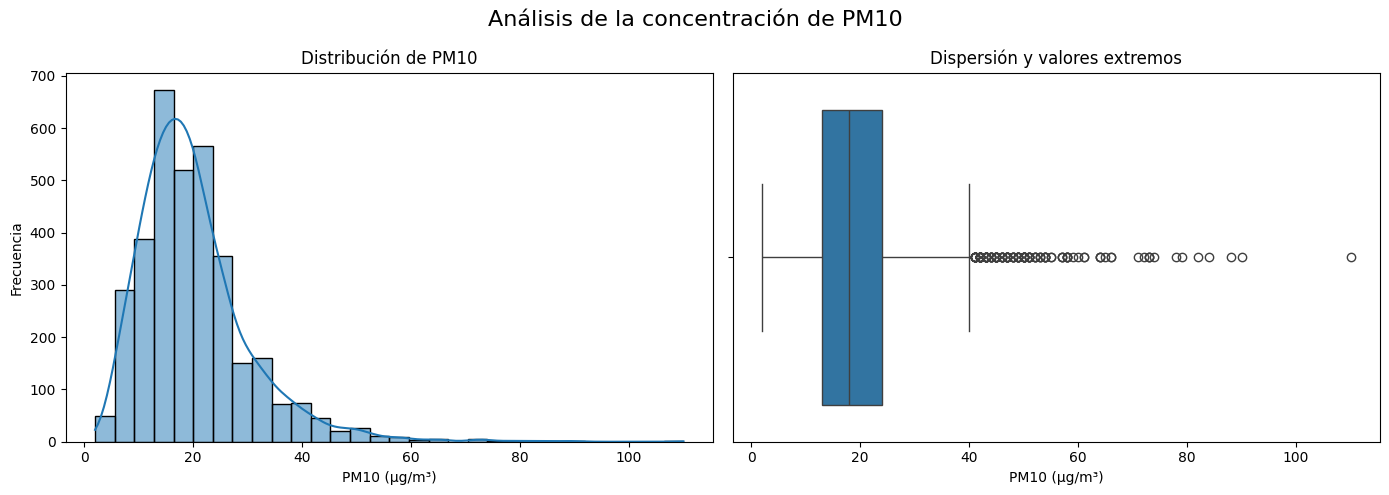

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Análisis de la concentración de PM10', fontsize=16)

# Histograma
sns.histplot(df[objetivo], bins=30, kde=True, ax=axes[0])
axes[0].set(
    title='Distribución de PM10',
    xlabel='PM10 (µg/m³)',
    ylabel='Frecuencia'
)

# Diagrama de caja
sns.boxplot(x=df[objetivo], ax=axes[1])
axes[1].set(
    title='Dispersión y valores extremos',
    xlabel='PM10 (µg/m³)'
)

plt.tight_layout()
plt.show()

- Histograma: las concentraciones de PM10 se agrupan principalmente entre 10 y 25 µg/m³. La distribución presenta asimetría hacia la derecha: hay pocos registros con concentraciones muy altas, que llegan aproximadamente a 110 µg/m³.
- Diagrama de caja: la mediana está cerca de 18 µg/m³, y el 50 % central de las mediciones se encuentra aproximadamente entre 13 y 24 µg/m³. Se observan posibles valores atípicos por encima de 40 µg/m³. Estos no necesariamente son errores; podrían corresponder a episodios de mayor contaminación.

# mapa de calor de correlaciones
- Cerca de +1: cuando una variable aumenta, PM10 tiende a aumentar.
- Cerca de −1: cuando una variable aumenta, PM10 tiende a disminuir.
- Cerca de 0: existe poca relación lineal con PM10.

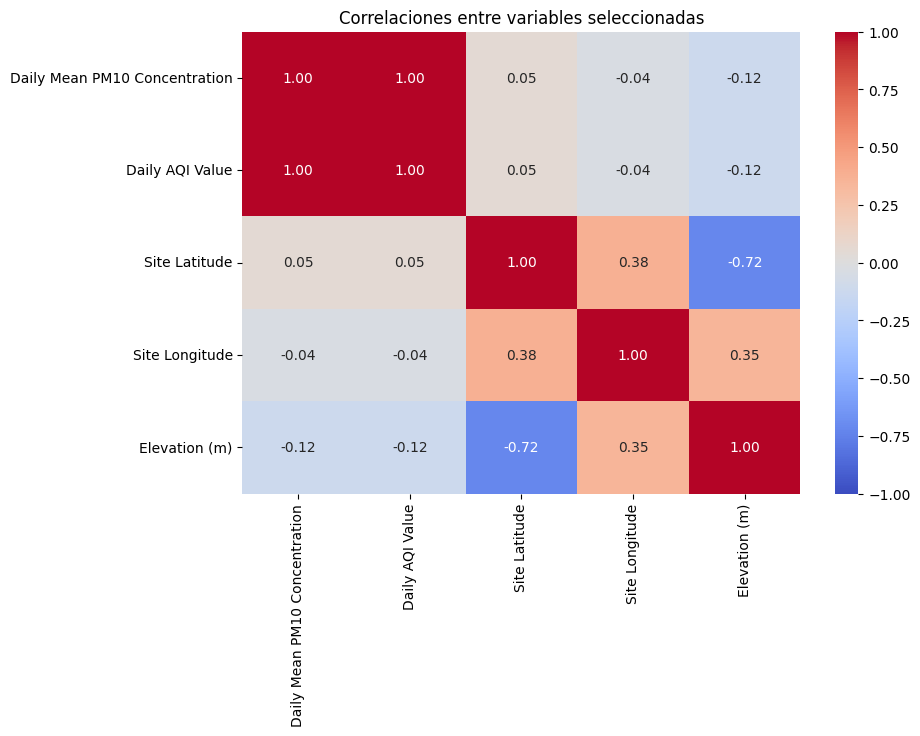

In [ ]:
# Seleccionamos las variables que queremos comparar
exploracion = [
    objetivo, 'Daily AQI Value',
    'Site Latitude', 'Site Longitude', 'Elevation (m)'
]

# Calculamos y mostramos sus correlaciones
plt.figure(figsize=(9, 6))
sns.heatmap(
    df[exploracion].corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', vmin=-1, vmax=1
)
plt.title('Correlaciones entre variables seleccionadas')
plt.show()

la concentración de PM10 presenta una correlación positiva casi perfecta con el AQI, mostrada como 1,00 por el redondeo. Esta relación se explica porque el AQI se calcula a partir de la concentración del contaminante; por ello, se excluye como predictor del modelo para evitar utilizar información derivada de la variable objetivo. En cambio, la latitud (0,05), longitud (−0,04) y elevación (−0,12) presentan relaciones lineales muy débiles con PM10. Los valores de 1,00 en la diagonal corresponden a cada variable comparada consigo misma y no aportan información sobre relaciones entre variables diferentes.

### División



In [ ]:
# Variables utilizadas para predecir
variables = ['Site Latitude', 'Site Longitude', 'Elevation (m)']
x = df[variables]

# Variable que queremos predecir
y = df['Daily Mean PM10 Concentration']

In [ ]:
x.head()

,Site Latitude,Site Longitude,Elevation (m)
0,33.553056,-86.815000,177
1,33.578333,-86.773889,173
2,33.499722,-86.924167,191
3,33.565278,-86.796389,179
4,33.499722,-86.924167,191


In [ ]:
y.head()

,Daily Mean PM10 Concentration
0,14
1,16
2,14
3,13
4,5


In [ ]:
from sklearn.model_selection import train_test_split

# Dividimos los datos: 70 % entrenamiento y 30 % prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=123
)

### entrenamiento

In [ ]:
from sklearn.linear_model import LinearRegression


lm = LinearRegression()

# Entrenamos el modelo para relacionar las variables de entrada
# (X_train) con la concentración real de PM10 (y_train)
lm.fit(X_train, y_train)

LinearRegression()

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

predicciones = lm.predict(X_test)

# Calculamos el error absoluto medio y el R²
mae = mean_absolute_error(y_test, predicciones)
r2 = r2_score(y_test, predicciones)

# Mostramos los resultados
print(f'MAE: {mae:.2f} µg/m³')
print(f'R²: {r2:.4f}')

MAE: 7.23 µg/m³
R²: 0.0598


### Resumen estadístico

- MAE: cuanto más cerca de 0, menor error.
- R²: cuanto más cerca de 1, mejor desempeño.

In [ ]:
# Importamos las métricas
from sklearn.metrics import mean_absolute_error, r2_score

# Predecimos PM10 con los datos de prueba
predicciones = lm.predict(X_test)

# Comparamos los valores reales con los predichos
mae = mean_absolute_error(y_test, predicciones)
r2 = r2_score(y_test, predicciones)

# Mostramos los resultados
print(f'MAE: {mae:.2f} µg/m³')
print(f'R²: {r2:.4f}')



MAE: 7.23 µg/m³
R²: 0.0598


In [ ]:
# Mostramos el intercepto del modelo
print('Intercepto:', lm.intercept_)

# Organizamos los coeficientes junto al nombre de cada variable
cdf = pd.DataFrame(
    {'Coeficiente': lm.coef_},
    index=X_train.columns
)

# Mostramos la tabla con cuatro decimales
display(cdf.round(4))

Intercepto: 25300.54637875424


,Coeficiente
Site Latitude,-532.1994
Site Longitude,81.8109
Elevation (m),-1.7880


In [ ]:
# numero de datos de entrenamiento
n = X_train.shape[0]

# numero de variables predictoras
k = X_train.shape[1]

# grados de libertad
dfN = n - k

# predicciones sobre los datos de entrenamiento
train_pred = lm.predict(X_train)

# error al cuadrado
train_error = np.square(train_pred - y_train)

# suma de errores
sum_error = np.sum(train_error)

# lista donde guardaremos los errores estándar
se = [0] * len(X_train.columns)

# calculamos el error estándar de cada coeficiente
for i in range(k):

    r = sum_error / dfN

    r = r / np.sum(
        np.square(
            X_train[X_train.columns[i]]
            - X_train[X_train.columns[i]].mean()
        )
    )

    se[i] = np.sqrt(r)

# agregamos el error estandar a la tabla
cdf['Standard Error'] = se

# calculamos el estadístico t
cdf['t-statistic'] = (
    cdf['Coeficiente'] /
    cdf['Standard Error']
)

display(cdf.round(4))

,Coeficiente,Standard Error,t-statistic
Site Latitude,-532.1994,7.3528,-72.3803
Site Longitude,81.8109,1.5962,51.2530
Elevation (m),-1.7880,0.0233,-76.8502


### Conclusión
Los **coeficientes** indican cómo influye cada variable en la predicción del PM10.

- **Standard Error:** mientras más pequeño sea respecto al coeficiente, más precisa es la estimación.
- **t-statistic:** mientras mayor sea su valor absoluto `|t|`, mayor evidencia de que el coeficiente es distinto de 0. El signo `+` o `-` solo indica la dirección de la relación.

En este modelo, la **latitud** y la **elevación** tienen relación negativa con el PM10, mientras que la **longitud** tiene relación positiva.

In [ ]:
# Comparamos los valores reales de PM10 con los predichos
comparacion = pd.DataFrame({
    'PM10 real': y_test,
    'PM10 predicho': predicciones
})

display(comparacion.head(10).round(2))

,PM10 real,PM10 predicho
3152,20,21.80
646,15,19.16
776,18,18.44
2306,35,19.16
956,18,16.18
1533,16,24.74
1660,14,24.74
2111,11,24.74
835,27,18.44
1698,11,19.16


las predicciones muestran que el modelo no logra representar adecuadamente las variaciones diarias de PM10. Esto concuerda con el bajo R² obtenido (0,0598). Las características geográficas utilizadas permiten distinguir ubicaciones, pero resultan insuficientes para explicar los cambios de concentración a lo largo del tiempo.

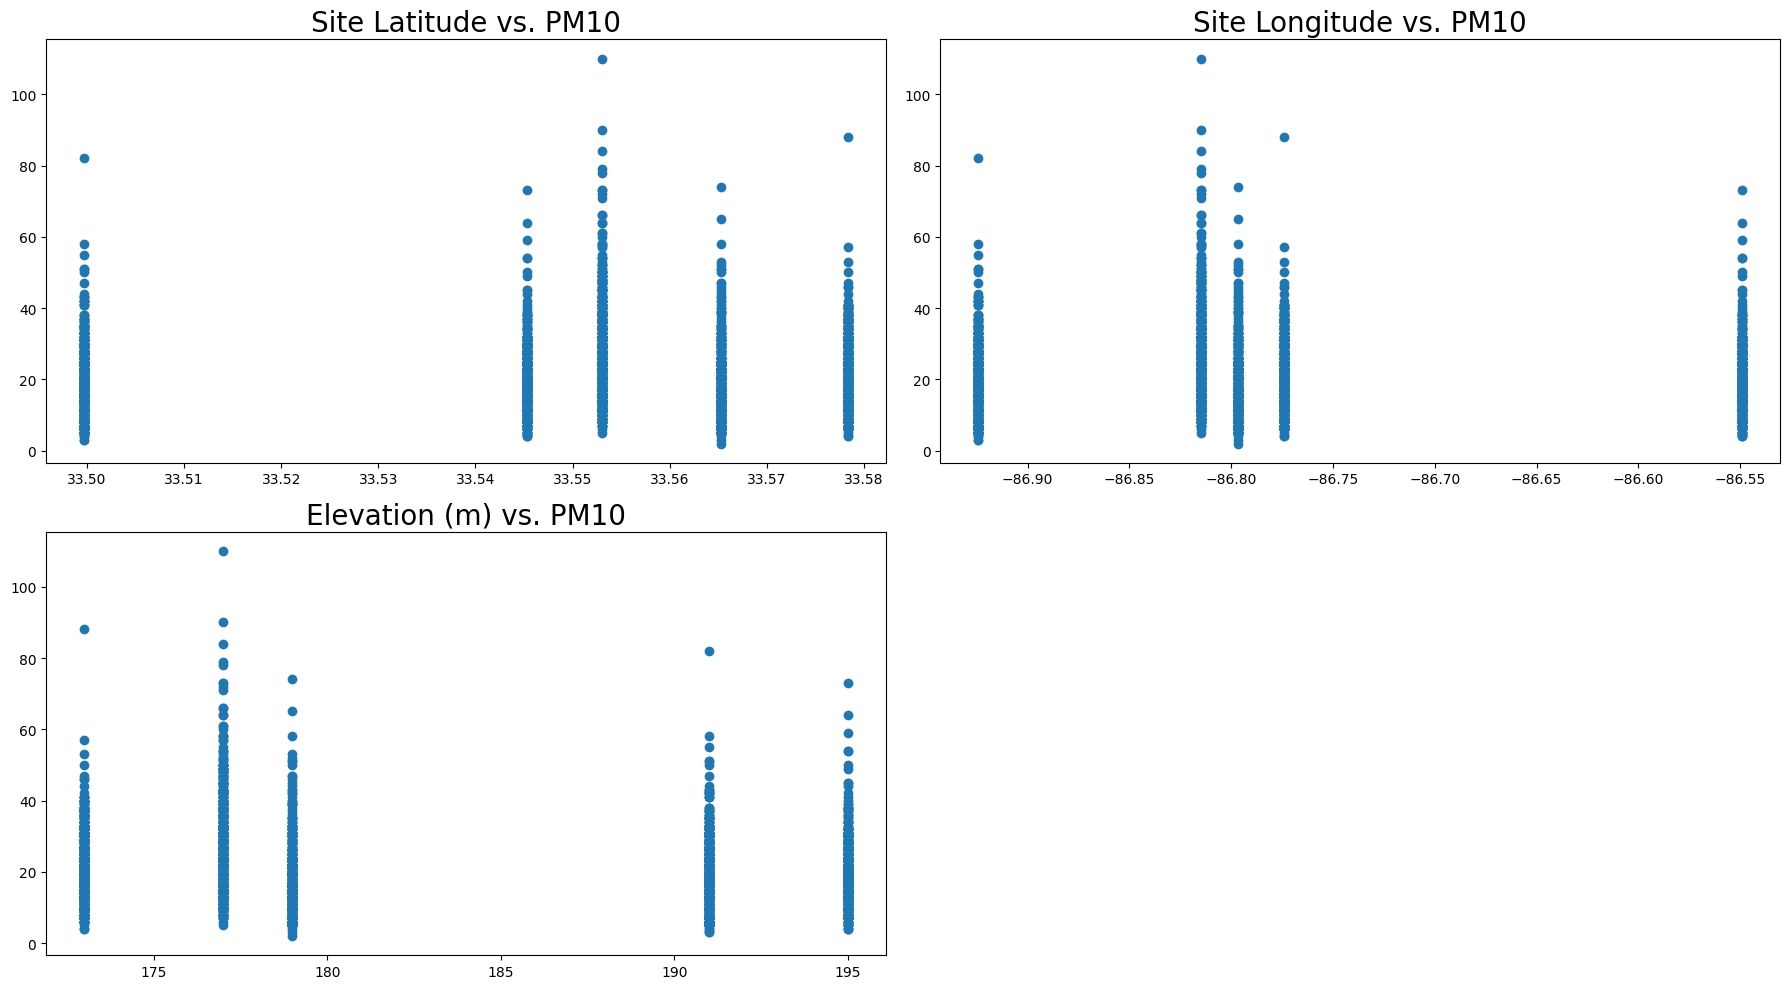

In [ ]:
from matplotlib import gridspec

# Variables predictoras
l = ['Site Latitude', 'Site Longitude', 'Elevation (m)']

fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 2)

# Site Latitude
ax0 = plt.subplot(gs[0])
ax0.scatter(df[l[0]], df['Daily Mean PM10 Concentration'])
ax0.set_title(
    l[0] + ' vs. PM10',
    fontdict={'fontsize': 20}
)

# Site Longitude
ax1 = plt.subplot(gs[1])
ax1.scatter(df[l[1]], df['Daily Mean PM10 Concentration'])
ax1.set_title(
    l[1] + ' vs. PM10',
    fontdict={'fontsize': 20}
)

# Elevation
ax2 = plt.subplot(gs[2])
ax2.scatter(df[l[2]], df['Daily Mean PM10 Concentration'])
ax2.set_title(
    l[2] + ' vs. PM10',
    fontdict={'fontsize': 20}
)

plt.tight_layout()
plt.show()

Los gráficos no muestran una relación lineal clara entre la latitud, longitud o elevación y la concentración de PM10. Esto se observa porque, para un mismo valor de cada variable, existen concentraciones de PM10 muy diferentes.

Las agrupaciones verticales se deben a que las mediciones provienen de estaciones fijas con la misma ubicación y elevación.

In [ ]:
predictions = lm.predict(X_test)

print("Tipo del objeto predicho:", type(predictions))
print("Tamaño del objeto predicho:", predictions.shape)

Tipo del objeto predicho: <class 'numpy.ndarray'>
Tamaño del objeto predicho: (1029,)


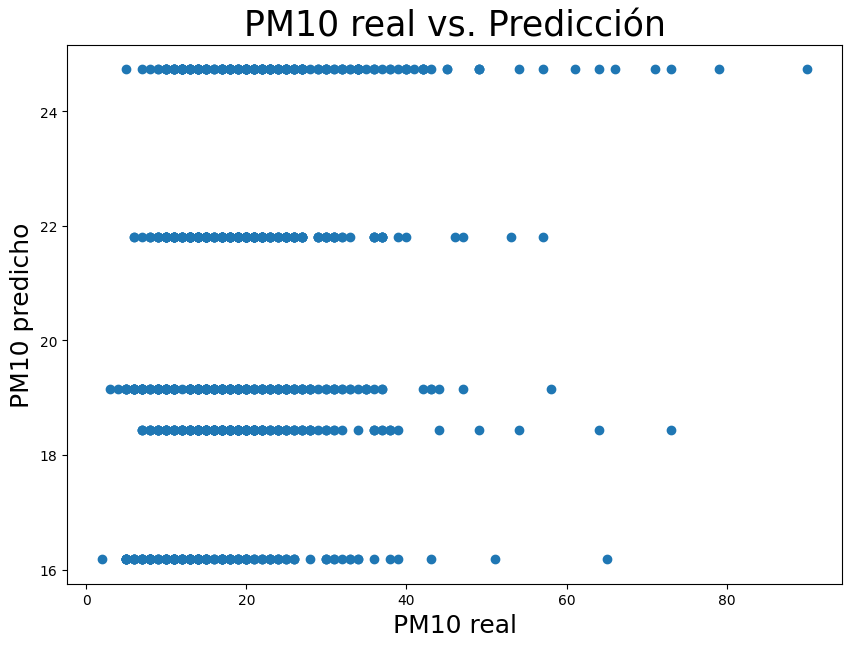

In [ ]:
plt.figure(figsize=(10,7))

plt.title("PM10 real vs. Predicción", fontsize=25)
plt.xlabel("PM10 real", fontsize=18)
plt.ylabel("PM10 predicho", fontsize=18)

plt.scatter(
    x=y_test,
    y=predictions
)

plt.show()

Los valores predichos forman bandas horizontales y no una tendencia diagonal. Esto indica que el modelo genera predicciones similares para cada ubicación, aunque los valores reales de PM10 varíen considerablemente.

Por ello, la latitud, longitud y elevación por sí solas no permiten explicar adecuadamente las variaciones diarias del PM10.

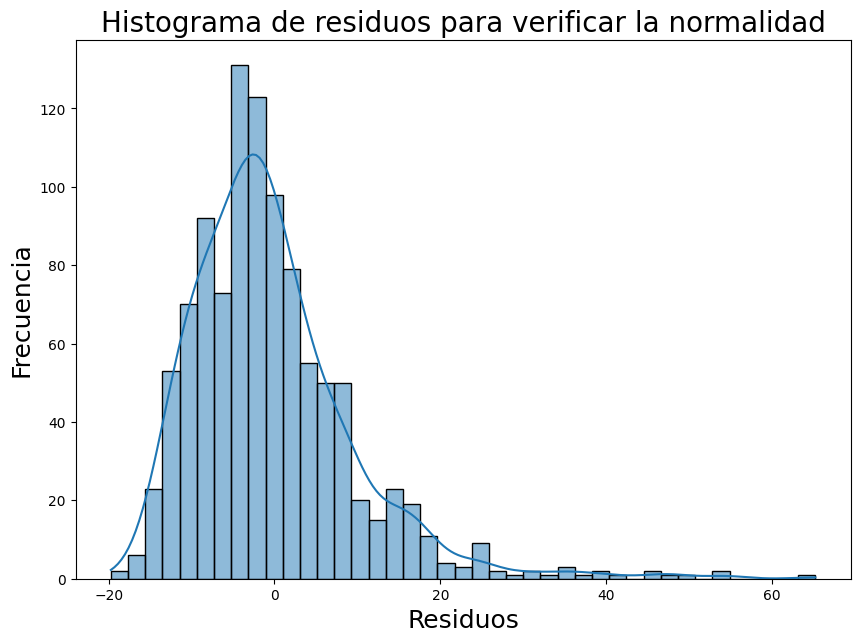

In [ ]:
residuos = y_test - predictions
residuos = y_test - predictions

plt.figure(figsize=(10,7))

plt.title(
    "Histograma de residuos para verificar la normalidad",
    fontsize=20
)

plt.xlabel("Residuos", fontsize=18)
plt.ylabel("Frecuencia", fontsize=18)

sns.histplot(
    residuos,
    kde=True
)

plt.show()


Los residuos se concentran cerca de cero, pero presentan una **asimetría positiva** y una cola larga hacia la derecha.

Esto indica que el modelo tiende a **subestimar algunos valores altos de PM10** y que los residuos no siguen claramente una distribución normal.

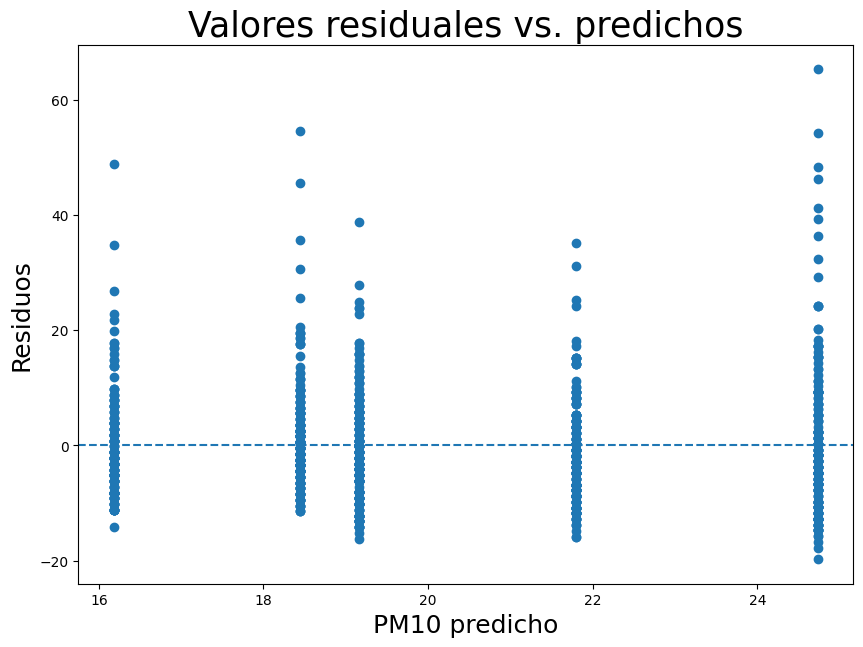

In [ ]:
plt.figure(figsize=(10,7))

plt.title("Valores residuales vs. predichos", fontsize=25)
plt.xlabel("PM10 predicho", fontsize=18)
plt.ylabel("Residuos", fontsize=18)

plt.scatter(
    x=predictions,
    y=y_test - predictions
)

plt.axhline(y=0, linestyle="--")

plt.show()

Aunque se utilizó un modelo de **regresión lineal**, los datos no presentan una relación lineal clara con el PM10.

Idealmente, los residuos deberían distribuirse como una nube aleatoria alrededor de cero.

En este modelo aparecen bandas verticales y varios residuos alejados de cero, lo que indica que las predicciones son poco variables y que el modelo no captura completamente los cambios del PM10.

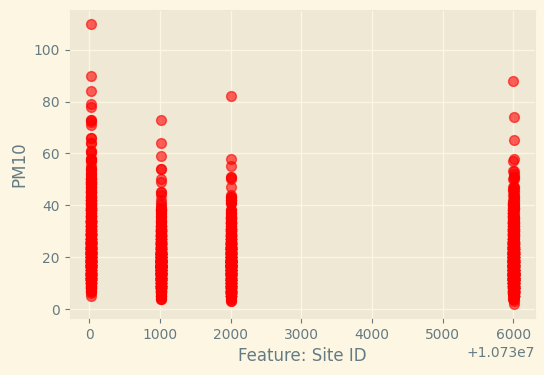

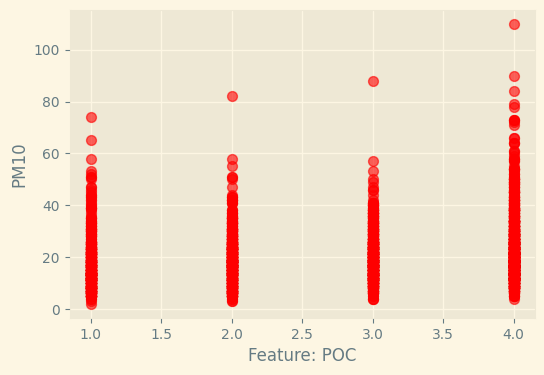

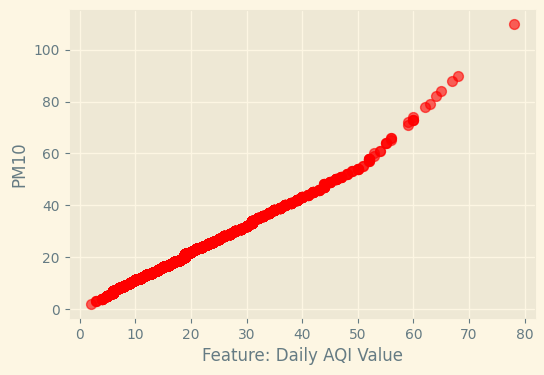

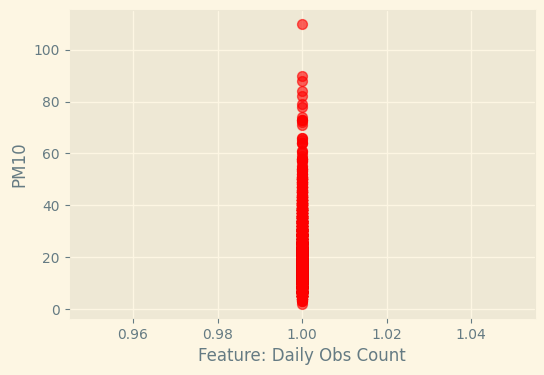

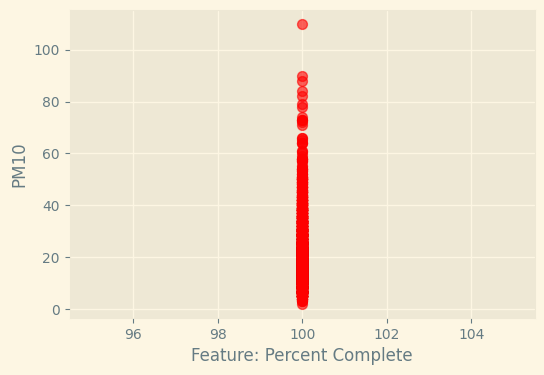

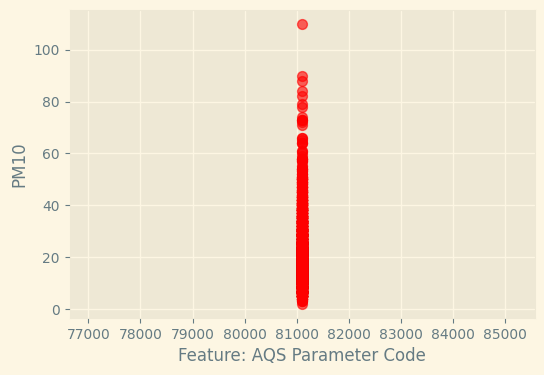

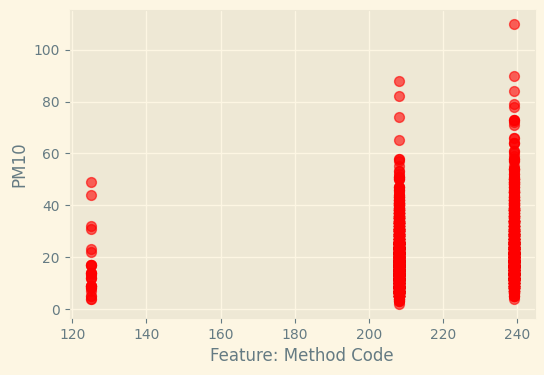

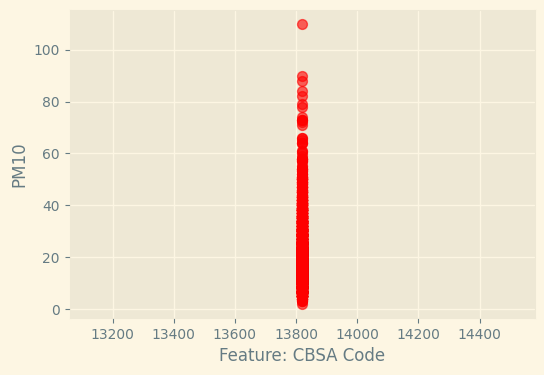

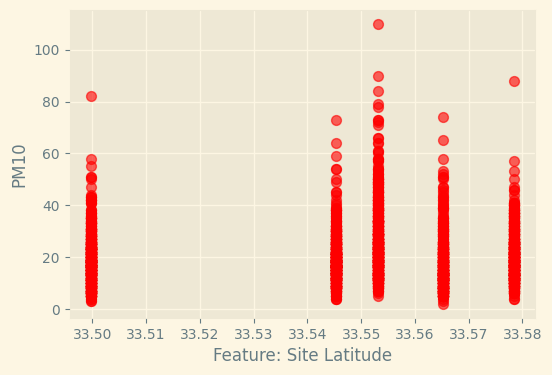

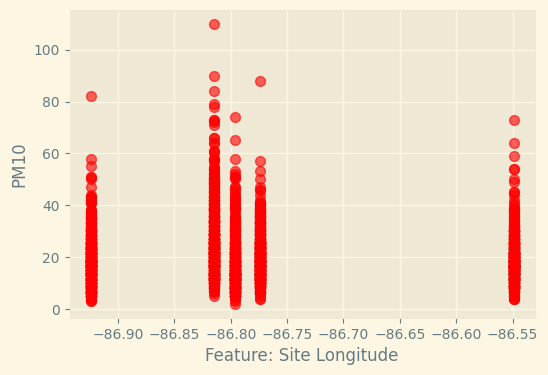

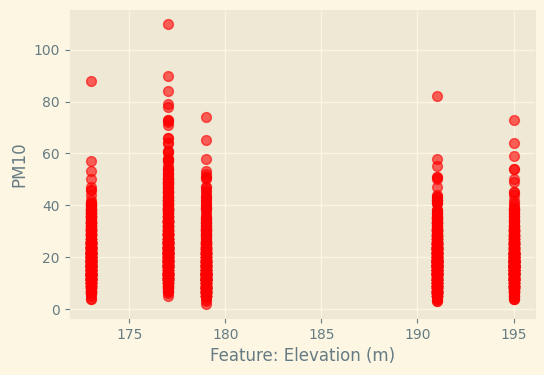

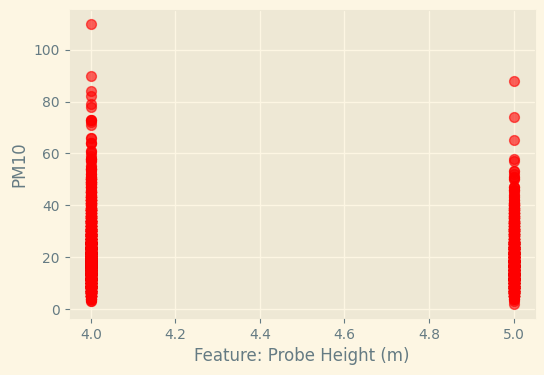

In [ ]:
objetivo = 'Daily Mean PM10 Concentration'

# Todas las columnas numéricas excepto el objetivo
variables = df.select_dtypes(include='number').columns.drop(objetivo)

with plt.style.context('Solarize_Light2'):

    for col in variables:

        plt.figure(figsize=(6, 4))

        plt.grid(True)

        plt.xlabel('Feature: ' + col, fontsize=12)
        plt.ylabel('PM10', fontsize=12)

        plt.scatter(
            df[col],
            df[objetivo],
            c='red',
            s=50,
            alpha=0.6
        )

        plt.show()

La variable `Daily AQI Value` presenta una relación positiva muy fuerte con la concentración de PM10: a medida que aumenta el AQI, también aumenta el PM10.

Sin embargo, esta variable no debería utilizarse como predictor del PM10, ya que el AQI se obtiene a partir de la concentración del contaminante. Su uso produciría fuga de información y daría una impresión artificialmente buena del modelo.

Las demás variables presentan principalmente agrupaciones verticales debido a que corresponden a características fijas de las estaciones de monitoreo.

## Uso de datos artificiales

Después de evaluar el modelo con los datos reales de PM10, se observa que la regresión lineal no logra representar completamente su variabilidad.

Por ello, se continúa con una sección de **datos artificiales generados con `make_regression`**. Estos datos no se utilizan para corregir ni reemplazar los datos reales de PM10, sino para analizar y practicar el funcionamiento de una regresión lineal en un conjunto de datos creado específicamente para este tipo de modelo.

De esta manera, se puede comparar el comportamiento de la regresión con datos reales frente a datos generados bajo una relación lineal conocida.

# Regresión lineal para estimar PM10 y comparación con un árbol de decisión en datos artificiales

In [ ]:
from sklearn.datasets import make_regression

# Generamos datos artificiales separados de PM10
X_artificial, y_artificial, coef_reales = make_regression(
    n_samples=100,
    n_features=6,
    n_informative=3,
    noise=20,
    shuffle=False,
    coef=True,
    random_state=20
)

# Organizamos los datos en una tabla
df_artificial = pd.DataFrame(
    X_artificial,
    columns=['x1', 'x2', 'x3', 'x4', 'x5', 'x6']
)
df_artificial['y'] = y_artificial

display(df_artificial.head())
print('Coeficientes reales:', coef_reales)

,x1,x2,x3,x4,x5,x6,y
0,0.883893,0.195865,0.357537,-2.343262,-1.084833,0.559696,109.512132
1,0.939469,-0.978481,0.503097,0.406414,0.323461,-0.493411,52.542242
2,-0.792017,-0.842368,-1.279503,0.245715,-0.044195,1.567633,-247.679018
3,1.051109,0.406368,-0.168646,-3.189703,1.120132,1.332778,98.678111
4,-0.243339,-0.130031,-0.109017,1.556186,0.128778,-2.066949,-55.286890


Coeficientes reales: [78.58638696 97.72361019 52.30606265  0.          0.          0.        ]


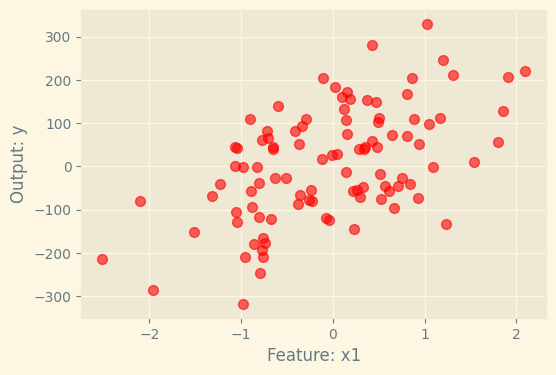

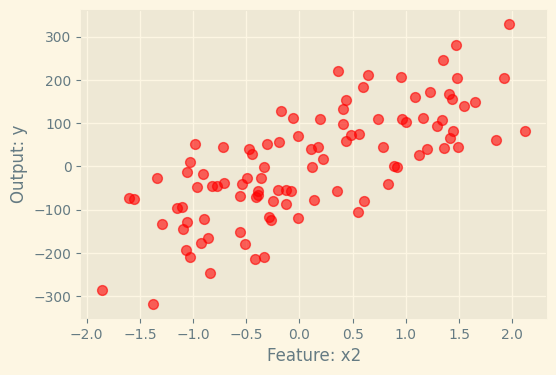

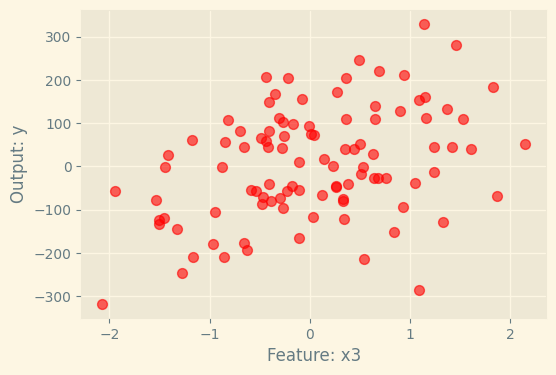

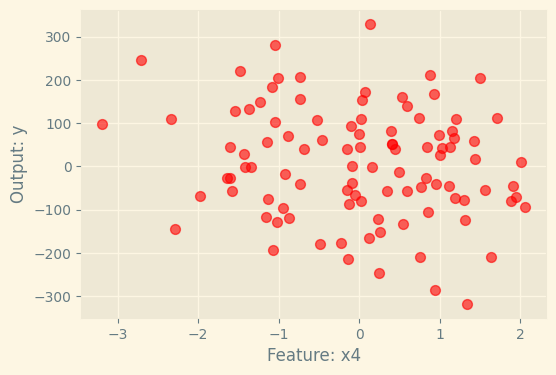

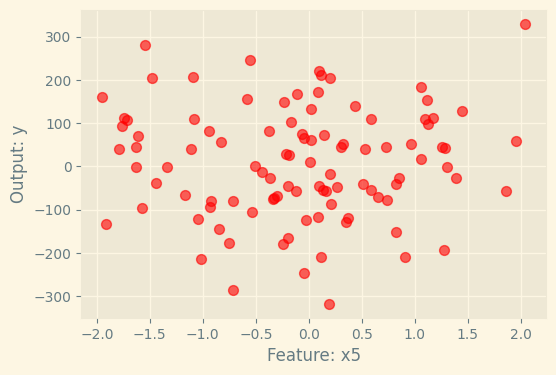

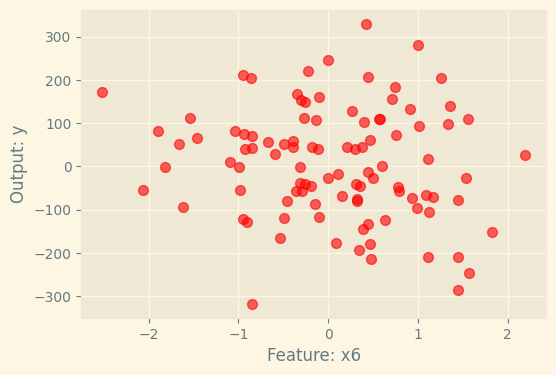

In [ ]:
with plt.style.context('Solarize_Light2'):

    for col in df_artificial.columns[:-1]:

        plt.figure(figsize=(6, 4))

        plt.grid(True)

        plt.xlabel('Feature: ' + col, fontsize=12)

        plt.ylabel('Output: y', fontsize=12)

        plt.scatter(
            df_artificial[col],
            df_artificial['y'],
            c='red',
            s=50,
            alpha=0.6
        )

        plt.show()

### Interpretación

Los gráficos muestran que `x1`, `x2` y `x3` presentan una relación positiva con la variable objetivo `y`, siendo `x2` la que muestra visualmente la tendencia más clara.

En cambio, `x4`, `x5` y `x6` presentan una distribución dispersa sin una tendencia definida, indicando que no tienen una relación directa con `y`.

Esto coincide con la generación de los datos artificiales, ya que se definieron **6 variables, de las cuales solo 3 son informativas**.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# División: 70 % entrenamiento y 30 % prueba
X_train_art, X_test_art, y_train_art, y_test_art = train_test_split(
    X_artificial, y_artificial,
    test_size=0.30, random_state=123
)

# Entrenamiento
lm_art = LinearRegression()
lm_art.fit(X_train_art, y_train_art)

# Predicción y evaluación
pred_art = lm_art.predict(X_test_art)

print(f'MAE: {mean_absolute_error(y_test_art, pred_art):.2f}')
print(f'R²: {r2_score(y_test_art, pred_art):.4f}')

MAE: 16.26
R²: 0.9756


In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Entrenamiento del árbol
arbol_art = DecisionTreeRegressor(max_depth=5, random_state=10)
arbol_art.fit(X_train_art, y_train_art)

# Predicciones
pred_arbol_art = arbol_art.predict(X_test_art)

# Comparación sobre los mismos datos de prueba
comparacion_art = pd.DataFrame({
    'Modelo': ['Regresión lineal', 'Árbol de decisión'],
    'MAE': [
        mean_absolute_error(y_test_art, pred_art),
        mean_absolute_error(y_test_art, pred_arbol_art)
    ],
    'R²': [
        r2_score(y_test_art, pred_art),
        r2_score(y_test_art, pred_arbol_art)
    ]
})

display(comparacion_art.round(4))

,Modelo,MAE,R²
0,Regresión lineal,16.2615,0.9756
1,Árbol de decisión,69.8909,0.5459


La regresión tiene menor error y explica aproximadamente el 97,56 % de la variación en los datos de prueba. El árbol explica el 54,59 %

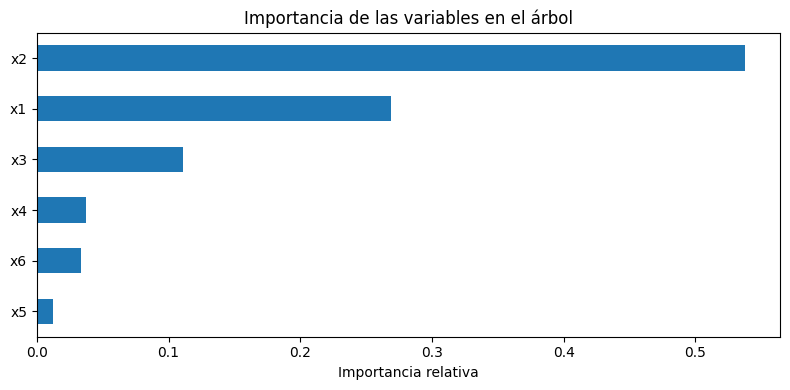

In [ ]:
# Importancia de cada variable
importancias_art = pd.Series(
    arbol_art.feature_importances_,
    index=df_artificial.columns[:-1]
).sort_values()

importancias_art.plot.barh(figsize=(8, 4))
plt.title('Importancia de las variables en el árbol')
plt.xlabel('Importancia relativa')
plt.tight_layout()
plt.show()

### Interpretación de la importancia de las variables

- **x2 (≈54 %)** es la variable con mayor importancia en el árbol.
- **x1 (≈27 %)** ocupa el segundo lugar.
- **x3 (≈11 %)** también contribuye a las predicciones.
- **x4, x5 y x6 (≈8 % en conjunto)** tienen poca importancia.

In [ ]:
import statsmodels.api as sm

# Añadimos el intercepto y ajustamos con los datos de entrenamiento
Xs_art = sm.add_constant(X_train_art)
ols_art = sm.OLS(y_train_art, Xs_art).fit()

print(ols_art.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.974
Model:                            OLS   Adj. R-squared:                  0.972
Method:                 Least Squares   F-statistic:                     399.3
Date:                Fri, 18 Sep 2026   Prob (F-statistic):           3.86e-48
Time:                        21:36:44   Log-Likelihood:                -308.89
No. Observations:                  70   AIC:                             631.8
Df Residuals:                      63   BIC:                             647.5
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.3498      2.568     -2.083      0.0